In [1]:
import torch
import numpy as np
import pandas as pd
import scanpy as sc
from typing import Tuple

# scVI imports
import scvi
import pymde

torch.manual_seed(0)
np.random.seed(0)

import sys
sys.path.append('..')
# from tools.reduction.reduction import run_dimension_reduction, run_clustering
# from tools.evaluation.monitor import *
from tools.evaluation.clustering import clustering_metrics

/opt/conda/lib/python3.11/site-packages/jaxlib/plugin_support.py:71: RuntimeWarning: JAX plugin jax_cuda12_plugin version 0.6.2 is installed, but it is not compatible with the installed jaxlib version 0.6.1, so it will not be used.
  warnings.warn(


In [7]:
# !pip install GPUtil

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com


In [7]:
# !pip3 install nvidia-ml-py3

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
  Preparing metadata (setup.py) ... done
  DEPRECATION: Building 'nvidia-ml-py3' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'nvidia-ml-py3'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  Created wheel for nvidia-ml-py3: filename=nvidia_ml_py3-7.352.0-py3-none-any.whl size=19206 sha256=9fd7cc2a5ac1d3b1ebfdf1ea23e3d94c2835984524fb97cc49117981ab8f8cc3
  Stored in directory: /tmp/pip-ephem-wheel-cache-2e4o2v4l/wheels/47/50/9e/29dc79037d74c3c1bb4a8661fb608e8674b7e4260d6a3f8f51
Successfully built nvidia-ml-py3


In [2]:
import os
import time
import psutil
# import GPUtil
from threading import Thread
from pynvml import *
import GPUtil


class Monitor(Thread):
    def __init__(self, delay=1):
        super(Monitor, self).__init__()
        self.stopped = False
        self.delay = delay # Time between calls to GPUtil
        self.time_points = []
        self.cpu_usage = []
        self.mem_usage = []
        self.gpu_usage = []
        self.gpu_mem_usage = []
        self.gpu_total = []
        self.gpu_used = []
        self.start()


    def run(self):
        while not self.stopped:
            # Obtaining all the essential details
            self.time_points.append(time.time())
            self.cpu_usage.append(psutil.cpu_percent())
            self.mem_usage.append(psutil.virtual_memory().percent)
            self.gpu_usage.append(self.get_nvidia_info()['gpus'][0]['gpu_utilization'])
            self.gpu_mem_usage.append(self.get_nvidia_info()['gpus'][0]['memory_utilization'])
            self.gpu_total.append(self.get_nvidia_info()['gpus'][0]['total'])
            self.gpu_used.append(self.get_nvidia_info()['gpus'][0]['used'])
            time.sleep(self.delay)
        

    def stop(self):
        self.stopped = True
        return self.time_points, self.cpu_usage, self.mem_usage, self.gpu_usage, self.gpu_mem_usage, self.gpu_total, self.gpu_used
    

    def get_sys_info(self) -> dict:
        sys_info: dict = {}
        cpu, ram = self.get_cpu_mem_info()
        gpus = self.get_nvidia_info()
        sys_info['CPU'] = cpu
        sys_info['RAM'] = ram
        if len(gpus['gpus']) > 0:
            gpu_list = []
            for i in range(len(gpus['gpus'])):
                gpu = f"{gpus['gpus'][i]['gpu_model']} @ {gpus['gpus'][i]['total']} GB"
                gpu_list.append(gpu)
            
            sys_info['GPU'] = gpu_list

        return sys_info
    

    def get_cpu_mem_info(self):
        import platform

        n_cores = psutil.cpu_count(logical=False)
        # n_thread = psutil.cpu_count()
        freq = float('{:.2f}'.format(psutil.cpu_freq().current / 1000)) # GHz
        cpu_model = platform.processor()
        mem_total = round(psutil.virtual_memory().total / 1024 / 1024 / 1024, 2) # GB
        # mem_free = round(psutil.virtual_memory().available / 1024 / 1024 / 1024, 2) # GB
        # mem_process_used = round(psutil.Process(os.getpid()).memory_info().rss / 1024 / 1024 / 1024, 2) # GB
        cpu = f"{cpu_model} {n_cores}-core @ {freq} GHz"
        ram = f"{mem_total} GB"

        return cpu, ram
    

    def get_nvidia_info(self):
        nvidia_dict = {
            "state": True,
            "nvidia_version": "",
            "nvidia_count": 0,
            "gpus": []
        }

        gpus = GPUtil.getGPUs()
        for gpu in gpus:
            print(f"GPU ID: {gpu.id}")
            print(f"  Name: {gpu.name}")
            print(f"  Load: {gpu.load*100:.2f}%")
            print(f"  Memory Used: {gpu.memoryUsed:.2f}MB")
            print(f"  Memory Total: {gpu.memoryTotal:.2f}MB")
        
        try:
            import nvidia_smi
            
            nvidia_smi.nvmlInit()

            nvidia_dict["nvidia_version"] = nvmlSystemGetDriverVersion()
            nvidia_dict["nvidia_count"] = nvmlDeviceGetCount()
            for i in range(nvidia_dict["nvidia_count"]):
                handle = nvmlDeviceGetHandleByIndex(i)
                res = nvidia_smi.nvmlDeviceGetUtilizationRates(handle)
                print(f'gpu: {res.gpu}%, gpu-mem: {res.memory}%')
                name = nvmlDeviceGetName(handle)
                memory_info = nvmlDeviceGetMemoryInfo(handle)
                utilization = nvmlDeviceGetUtilizationRates(handle)

                print(f"GPU {i}: {name}")
                print(f"  Memory Total: {memory_info.total / (1024**3):.2f} GB")
                print(f"  Memory Used: {memory_info.used / (1024**3):.2f} GB")
                print(f"  GPU Utilization: {utilization.gpu}%")
                print(f"  Memory Utilization: {round(memory_info.used / memory_info.total, 2)}%")
                
                gpu = {
                    "gpu_model": nvmlDeviceGetName(handle),
                    "total": round(memory_info.total / 1024 / 1024 / 1024, 2), # GB
                    "free": round(memory_info.free / 1024 / 1024 / 1024, 2), # GB
                    "used": round(memory_info.used / 1024 / 1024 / 1024, 2), # GB
                    "gpu_utilization": utilization.gpu, 
                    "memory_utilization": round(memory_info.used * 100 / memory_info.total, 2), 
                    "temperature": f"{nvmlDeviceGetTemperature(handle, 0)}℃",
                    "powerStatus": nvmlDeviceGetPowerState(handle)
                }
                nvidia_dict['gpus'].append(gpu)
        except NVMLError as _:
            nvidia_dict["state"] = False
        except Exception as _:
            nvidia_dict["state"] = False
        finally:
            try:
                nvmlShutdown()
            except:
                pass
        return nvidia_dict


    def gpu_mem_percent(self):
        mem_rate = 0.0
        info = self.get_nvidia_info()
        if len(info['gpus']) > 0:
            used = info['gpus'][0]['used']
            tot = info['gpus'][0]['total']
            memory_utilization = info['gpus'][0]['memory_utilization']
            gpu_utilization = info['gpus'][0]['gpu_utilization']

        return gpu_utilization, memory_utilization


In [2]:
adata = sc.read_h5ad('../../../oscb/user_storage/Benchmarks/GTEX-v9_1760570250226/QC/GTEX_v9_scanpy.h5ad')
adata

AnnData object with n_obs × n_vars = 209126 × 2000
    obs: 'soma_joinid', 'dataset_id', 'assay', 'assay_ontology_term_id', 'cell_type', 'cell_type_ontology_term_id', 'development_stage', 'development_stage_ontology_term_id', 'disease', 'disease_ontology_term_id', 'donor_id', 'is_primary_data', 'self_reported_ethnicity', 'self_reported_ethnicity_ontology_term_id', 'sex', 'sex_ontology_term_id', 'suspension_type', 'tissue', 'tissue_ontology_term_id', 'tissue_general', 'tissue_general_ontology_term_id', 'n_genes', 'batch', 'size_factors', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'doublet_score', 'predicted_doublet', 'clf_doublet', 'clf_score', 'leiden', 'louvain'
    var: 'soma_joinid', 'feature_id', 'feature_name', '

In [3]:
batch_key = 'batch'
if 'pct_counts_mt' in adata.obs.keys() and 'pct_counts_ribo' in adata.obs.keys():
    scvi.model.SCVI.setup_anndata(adata, categorical_covariate_keys = [batch_key], continuous_covariate_keys=['pct_counts_mt', 'pct_counts_ribo'])
else:
    scvi.model.SCVI.setup_anndata(adata, categorical_covariate_keys = [batch_key])

In [4]:
model_path = '../../../oscb/user_storage/Benchmarks/GTEX-v9_1760570250226/QC/batch_integration_model'
model = scvi.model.SCVI.load(model_path, adata)

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


INFO     File ../../../oscb/user_storage/Benchmarks/GTEX-v9_1760570250226/QC/batch_integration_model/model.pt      
         already downloaded                                                                                        


In [5]:
adata.obsm["X_scVI"] = model.get_latent_representation()
adata.layers['scvi_normalized'] = model.get_normalized_expression(library_size = 1e4)

In [6]:
from tools.evaluation.integration import integration_metrics

In [7]:
metrics_dict = integration_metrics(adata, adata, batch_key=batch_key, label_key='cell_type', species="human")

Recompute neighbors on rep X_pca instead of None
Cluster for cluster_0.2 with leiden


/opt/conda/lib/python3.11/site-packages/scib/metrics/clustering.py:96: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  cluster_function(adata, resolution=res, key_added=resolution_key, **kwargs)


Cluster for cluster_0.4 with leiden
Cluster for cluster_0.6 with leiden
Cluster for cluster_0.8 with leiden
Cluster for cluster_1.0 with leiden
Cluster for cluster_1.2 with leiden
Cluster for cluster_1.4 with leiden
Cluster for cluster_1.6 with leiden
Cluster for cluster_1.8 with leiden
Cluster for cluster_2.0 with leiden
NMI...
ARI...
Silhouette score...
PC regression...
Isolated labels F1...


/opt/conda/lib/python3.11/site-packages/scib/metrics/isolated_labels.py:311: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  batch_per_lab = tmp.groupby(label_key).agg({batch_key: "count"})


Cluster for iso_label_0.2 with leiden
Cluster for iso_label_0.4 with leiden
Cluster for iso_label_0.6 with leiden
Cluster for iso_label_0.8 with leiden
Cluster for iso_label_1.0 with leiden
Cluster for iso_label_1.2 with leiden
Cluster for iso_label_1.4 with leiden
Cluster for iso_label_1.6 with leiden
Cluster for iso_label_1.8 with leiden
Cluster for iso_label_2.0 with leiden
Cluster for iso_label_0.2 with leiden
Cluster for iso_label_0.4 with leiden
Cluster for iso_label_0.6 with leiden
Cluster for iso_label_0.8 with leiden
Cluster for iso_label_1.0 with leiden
Cluster for iso_label_1.2 with leiden
Cluster for iso_label_1.4 with leiden
Cluster for iso_label_1.6 with leiden
Cluster for iso_label_1.8 with leiden
Cluster for iso_label_2.0 with leiden
Isolated labels ASW...


...

/opt/conda/lib/python3.11/site-packages/scib/metrics/kbet.py:229: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  anndata2ri.activate()
/opt/conda/lib/python3.11/site-packages/scib/metrics/kbet.py:158: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  comp_size = pd.value_counts(labs)


Adding diffusion to step 4


/opt/conda/lib/python3.11/site-packages/scib/metrics/kbet.py:229: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  anndata2ri.activate()
/opt/conda/lib/python3.11/site-packages/scib/metrics/highly_variable_genes.py:30: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(i.obs[batch][0] + " has less than the specified number of genes")
/opt/conda/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:82: UserWarning: `n_top_genes` > number of normalized dispersions, returning all genes with normalized dispersions.
  return fn(*args_all, **kw)
/opt/conda/lib/python3.11/site-packages/scib/metrics/highly_variable_genes.py:35: FutureWarning: Series.__getitem__ treating keys as positions is deprecated.

GTEX-1CAMR has less than the specified number of genes
Number of genes: 515


/opt/conda/lib/python3.11/site-packages/scib/metrics/highly_variable_genes.py:35: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  hvg_dir[i.obs[batch][0]] = i.var.index[hvg["highly_variable"]]
/opt/conda/lib/python3.11/site-packages/scib/metrics/highly_variable_genes.py:35: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  hvg_dir[i.obs[batch][0]] = i.var.index[hvg["highly_variable"]]
/opt/conda/lib/python3.11/site-packages/scib/metrics/highly_variable_genes.py:35: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with 

In [8]:
metrics_dict

{'NMI_cluster/label': 0.8209,
 'ARI_cluster/label': 0.6285,
 'ASW_label': 0.5175,
 'ASW_label/batch': 0.8484,
 'PCR_batch': 0.0,
 'cell_cycle_conservation': 0.0,
 'isolated_label_F1': 0.1042,
 'isolated_label_silhouette': 0.5956,
 'graph_conn': 0.9526,
 'kBET': 0.3031,
 'iLISI': 0.0,
 'cLISI': 0.0,
 'hvg_overlap': 1.0,
 'trajectory': 0.0,
 'Biological Conservation': 0.6111}

In [43]:
from sklearn.manifold import TSNE
from umap import UMAP

def run_dimension_reduction(adata, layer=None, n_neighbors=15, use_rep=None, n_pcs=None, random_state=0, skip_if_exist=False):
    msg = None
    if layer == "Pearson_residuals":
        msg = "Normalize Pearson_residuals may create NaN values, which are not accepted by PCA."
        return adata, msg

    if n_pcs == 0:
        n_pcs=None

    if layer is not None and layer in adata.layers.keys(): # and (layer+'_umap' not in adata.obsm.keys() or layer+'_umap_3D' not in adata.obsm.keys()):
        # Principal component analysis
        if not (skip_if_exist and layer+'_pca' in adata.obsm.keys()):
            adata.obsm[layer+'_pca'] = sc.pp.pca(adata.layers[layer])

        # Computing the neighborhood graph
        if not (skip_if_exist and 'neighbors' in adata.uns.keys()):
            if use_rep is not None and n_pcs is not None and adata.obsm[use_rep].shape[1] < n_pcs:
                msg = f"{use_rep} does not have enough Dimensions. Set n_pcs to {adata.obsm[use_rep].shape[1]}."
                n_pcs = adata.obsm[use_rep].shape[1]

            if use_rep is None:
                use_rep = layer+'_pca'

            sc.pp.neighbors(adata, n_neighbors=n_neighbors, n_pcs=n_pcs, use_rep=use_rep, random_state=random_state)
        
        # tSNE
        if not (skip_if_exist and layer+'_tsne' in adata.obsm.keys()):
            tsne = TSNE(n_components=2, random_state=random_state)
            adata.obsm[layer+'_tsne'] = tsne.fit_transform(adata.obsm[layer+'_pca'])

        if not (skip_if_exist and layer+'_tsne_3D' in adata.obsm.keys()):
            tsne = TSNE(n_components=3, random_state=random_state)
            adata.obsm[layer+'_tsne_3D'] = tsne.fit_transform(adata.obsm[layer+'_pca'])
        
        # UMAP
        if not (skip_if_exist and layer+'_umap' in adata.obsm.keys()):
            umap_2d = UMAP(n_components=2, init='random', random_state=random_state)
            adata.obsm[layer+'_umap'] = umap_2d.fit_transform(adata.obsm[layer+'_pca'])

        if not (skip_if_exist and layer+'_umap_3D' in adata.obsm.keys()):
            umap_3d = UMAP(n_components=3, init='random', random_state=random_state)
            adata.obsm[layer+"_umap_3D"] = umap_3d.fit_transform(adata.obsm[layer+'_pca'])

    elif layer is None: # and ('X_umap' not in adata.obsm.keys() or 'X_umap_3D' not in adata.obsm.keys()):
        # Principal component analysis
        if not (skip_if_exist and 'X_pca' in adata.obsm.keys()):
            sc.pp.pca(adata, svd_solver='arpack', random_state=random_state)

        # Computing the neighborhood graph
        if not (skip_if_exist and 'neighbors' in adata.uns.keys()):
            if use_rep is not None and n_pcs is not None and adata.obsm[use_rep].shape[1] < n_pcs:
                msg = f"{use_rep} does not have enough Dimensions. Set n_pcs to {adata.obsm[use_rep].shape[1]}."
                n_pcs = adata.obsm[use_rep].shape[1]
            # elif use_rep is None:
            #     use_rep = 'X_pca'
            sc.pp.neighbors(adata, n_neighbors=n_neighbors, n_pcs=n_pcs, use_rep=use_rep, random_state=random_state)

        # tSNE
        if not (skip_if_exist and 'X_tsne' in adata.obsm.keys()):
            tsne = TSNE(n_components=2, random_state=random_state)
            adata.obsm['X_tsne'] = tsne.fit_transform(adata.obsm['X_pca'])

        # 3D tSNE
        if not (skip_if_exist and 'X_tsne_3D' in adata.obsm.keys()):
            tsne = TSNE(n_components=3, random_state=random_state)
            adata.obsm['X_tsne_3D'] = tsne.fit_transform(adata.obsm['X_pca'])

        # 2D UMAP
        if not (skip_if_exist and 'X_umap' in adata.obsm.keys()):
            umap_2d = UMAP(n_components=2, init='random', random_state=random_state)
            adata.obsm['X_umap'] = umap_2d.fit_transform(adata.obsm['X_pca'])
            # sc.tl.umap(adata, random_state=random_state, 
            #             init_pos="spectral", n_components=2, 
            #             copy=False, maxiter=None)
        
        # 3D UMAP
        if not (skip_if_exist and 'X_umap_3D' in adata.obsm.keys()):
            umap_3d = UMAP(n_components=3, init='random', random_state=random_state)
            adata.obsm["X_umap_3D"] = umap_3d.fit_transform(adata.obsm['X_pca'])
            # adata_3D = sc.tl.umap(adata, random_state=random_state, 
            #                 init_pos="spectral", n_components=3, 
            #                 copy=True, maxiter=None)
            # adata.obsm["X_umap_3D"] = adata_3D.obsm["X_umap"]
            # adata_3D = None
    else:
        # if layer is None: layer = 'X'
        # msg = f"{layer}_umap already exists, skipped."
        msg = f"{layer} does not exist, skipped."

    return adata, msg


def run_clustering(adata, layer=None, use_rep=None, resolution=0.5, random_state=0, skip_if_exist=False, fig_path=None):
    if layer == "Pearson_residuals":
        print("Normalize Pearson_residuals may create NaN values, which are not accepted by PCA.")
        return adata
    
    if fig_path is not None:
        if layer is None:
            fig_path = os.path.join(fig_path, 'leiden_clustering.png')
        else:
            fig_path = os.path.join(fig_path, layer+'_leiden_clustering.png')

    if skip_if_exist:
        if layer is not None and layer + '_louvain' in adata.obs.keys() and  layer + '_leiden' in adata.obs.keys():
            return adata
        elif layer is None and use_rep is not None and use_rep + '_louvain' not in adata.obs.keys() and use_rep + '_leiden' not in adata.obs.keys():
            return adata
        elif layer is None and 'louvain' not in adata.obs.keys() and 'leiden' not in adata.obs.keys():
            return adata
    
    if layer is not None: # and layer + '_louvain' not in adata.obs.keys():
        adata_temp = adata.copy()
        adata_temp.X = adata_temp.layers[layer]
        
        # Clustering the neighborhood graph
        sc.tl.leiden(adata_temp, resolution=resolution, 
                    random_state=random_state, n_iterations=3)
        # Save the Clustering plot
        if fig_path is not None:
            sc.pl.embedding(adata_temp, basis=layer+'_umap', color='leiden', show=False)
            plt.savefig(fig_path, dpi=300, bbox_inches='tight')

        adata.uns[layer + '_leiden'] = adata_temp.uns["leiden"].copy()
        adata.obs[layer + '_leiden'] = adata_temp.obs["leiden"].copy()

        sc.tl.louvain(adata_temp)
        adata.uns[layer + '_louvain'] = adata_temp.uns["louvain"].copy()
        adata.obs[layer + '_louvain'] = adata_temp.obs["louvain"].copy()
        adata_temp = None
    elif layer is None and use_rep is not None: # and use_rep + '_louvain' not in adata.obs.keys():
        leiden_key = "leiden_" + use_rep
        louvain_key = "louvain_" + use_rep
        sc.tl.leiden(adata, key_added = leiden_key, resolution=resolution, 
                    random_state=random_state, n_iterations=3)
        
        # Save the Clustering plot
        if fig_path is not None:
            sc.pl.umap(adata, color=leiden_key, show=False)
            plt.savefig(fig_path, dpi=300, bbox_inches='tight')

        sc.tl.louvain(adata, key_added = louvain_key)
    elif layer is None: # and 'louvain' not in adata.obs.keys():
        # Clustering the neighborhood graph
        leiden_key = "leiden"
        louvain_key = "louvain"

        if not is_normalized(adata.X, 200):
            adata.layers['raw_counts'] = adata.X.copy()
            sc.pp.normalize_total(adata)
            sc.pp.log1p(adata)

        sc.tl.leiden(adata, key_added = leiden_key, resolution=resolution, 
                    random_state=random_state, n_iterations=3)
        # Save the Clustering plot
        if fig_path is not None:
            sc.pl.umap(adata, color=leiden_key, show=False)
            plt.savefig(fig_path, dpi=300, bbox_inches='tight')

        sc.tl.louvain(adata, key_added = louvain_key)
    # else:
    #     if layer is None: layer = 'X'
    #     print(f"Cluster for {layer} already exists, skipped.")

    return adata

In [44]:
def scvi_clustering(adata, labels, model_path):
    # Start monitoring
    model = None
    monitor = Monitor(1)
    sys_info = monitor.get_sys_info()
    scvi.model.SCVI.setup_anndata(adata)
    if not os.path.exists(model_path):
        model = scvi.model.SCVI(adata, n_hidden = 192, n_latent = 50, n_layers = 1, gene_likelihood = 'zinb')
        model.train(max_epochs = 20, early_stopping = True)
        # model.save(model_path)
    else:
        try:
            model = scvi.model.SCVI.load(model_path, adata)
        except Exception as e:
            print(e)
            shutil.rmtree(model_path) # If the model_path exists but could not be loaded, then remove it and train a new one.
            model = scvi.model.SCVI(adata, n_hidden = 192, n_latent = 50, n_layers = 1, gene_likelihood = 'zinb')
            model.train(max_epochs = 400, early_stopping = True)
            model.save(model_path)

    latent = model.get_latent_representation()
    adata.obsm["X_scVI"] = latent
    # denoised = model.get_normalized_expression(adata, library_size=1e4)
    adata.layers["scvi_normalized"] = model.get_normalized_expression(
        library_size=10e4
    )

    adata, msg = run_dimension_reduction(adata, use_rep='X_scVI')
    adata = run_clustering(adata, use_rep='X_scVI')

    # adata.obsm["X_mde"] = pymde.preserve_neighbors(adata.obsm["X_scVI"])
    
    # Stop monitoring
    time_points, cpu_usage, mem_usage, gpu_usage, gpu_mem_usage, gpu_total, gpu_used = monitor.stop()

    asw_score, nmi_score, ari_score, fm_score = clustering_metrics(adata.obs[labels], adata.obs["leiden_X_scVI"], adata.obsm["X_scVI"])

    return adata, sys_info, asw_score, nmi_score, ari_score, fm_score, time_points, cpu_usage, mem_usage, gpu_usage, gpu_mem_usage, gpu_total, gpu_used

In [45]:
adata, sys_info, asw_score, nmi_score, ari_score, fm_score, time_points, cpu_usage, mem_usage, gpu_usage, gpu_mem_usage, gpu_total, gpu_used = scvi_clustering(adata, 'cell_ontology_class', './scvi')

/opt/conda/lib/python3.11/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.X does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


GPU ID: 0
  Name: Tesla P100-PCIE-12GB
  Load: 0.00%
  Memory Used: 731.00MB
  Memory Total: 12288.00MB
gpu: 0%, gpu-mem: 0%
GPU 0: Tesla P100-PCIE-12GB
  Memory Total: 12.00 GB
  Memory Used: 0.81 GB
  GPU Utilization: 0%
  Memory Utilization: 0.07%
GPU ID: 0
  Name: Tesla P100-PCIE-12GB
  Load: 0.00%
  Memory Used: 731.00MB
  Memory Total: 12288.00MB
gpu: 0%, gpu-mem: 0%
GPU 0: Tesla P100-PCIE-12GB
  Memory Total: 12.00 GB
  Memory Used: 0.81 GB
  GPU Utilization: 0%
  Memory Utilization: 0.07%
GPU ID: 0
  Name: Tesla P100-PCIE-12GB
  Load: 0.00%
  Memory Used: 731.00MB
  Memory Total: 12288.00MB
gpu: 0%, gpu-mem: 0%
GPU 0: Tesla P100-PCIE-12GB
  Memory Total: 12.00 GB
  Memory Used: 0.81 GB
  GPU Utilization: 0%
  Memory Utilization: 0.07%
GPU ID: 0
  Name: Tesla P100-PCIE-12GB
  Load: 0.00%
  Memory Used: 731.00MB
  Memory Total: 12288.00MB
gpu: 0%, gpu-mem: 0%
GPU 0: Tesla P100-PCIE-12GB
  Memory Total: 12.00 GB
  Memory Used: 0.81 GB
  GPU Utilization: 0%
  Memory Utilization: 0.

/opt/conda/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=39` in the `DataLoader` to improve performance.
/opt/conda/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=39` in the `DataLoader` to improve performance.


Training:   0%|          | 0/20 [00:00<?, ?it/s]

GPU ID: 0
  Name: Tesla P100-PCIE-12GB
  Load: 0.00%
  Memory Used: 725.00MB
  Memory Total: 12288.00MB
gpu: 0%, gpu-mem: 0%
GPU 0: Tesla P100-PCIE-12GB
  Memory Total: 12.00 GB
  Memory Used: 0.81 GB
  GPU Utilization: 0%
  Memory Utilization: 0.07%


...

GPU ID: 0
  Name: Tesla P100-PCIE-12GB
  Load: 9.00%
  Memory Used: 731.00MB
  Memory Total: 12288.00MB
gpu: 9%, gpu-mem: 1%
GPU 0: Tesla P100-PCIE-12GB
  Memory Total: 12.00 GB
  Memory Used: 0.81 GB
  GPU Utilization: 9%
  Memory Utilization: 0.07%
GPU ID: 0
  Name: Tesla P100-PCIE-12GB
  Load: 9.00%
  Memory Used: 731.00MB
  Memory Total: 12288.00MB
gpu: 4%, gpu-mem: 0%
GPU 0: Tesla P100-PCIE-12GB
  Memory Total: 12.00 GB
  Memory Used: 0.81 GB
  GPU Utilization: 4%
  Memory Utilization: 0.07%
GPU ID: 0
  Name: Tesla P100-PCIE-12GB
  Load: 4.00%
  Memory Used: 731.00MB
  Memory Total: 12288.00MB
gpu: 4%, gpu-mem: 0%
GPU 0: Tesla P100-PCIE-12GB
  Memory Total: 12.00 GB
  Memory Used: 0.81 GB
  GPU Utilization: 4%
  Memory Utilization: 0.07%
GPU ID: 0
  Name: Tesla P100-PCIE-12GB
  Load: 4.00%
  Memory Used: 731.00MB
  Memory Total: 12288.00MB
gpu: 4%, gpu-mem: 0%
GPU 0: Tesla P100-PCIE-12GB
  Memory Total: 12.00 GB
  Memory Used: 0.81 GB
  GPU Utilization: 4%
  Memory Utilization: 0.

/opt/conda/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


GPU ID: 0
  Name: Tesla P100-PCIE-12GB
  Load: 0.00%
  Memory Used: 731.00MB
  Memory Total: 12288.00MB
gpu: 0%, gpu-mem: 0%
GPU 0: Tesla P100-PCIE-12GB
  Memory Total: 12.00 GB
  Memory Used: 0.81 GB
  GPU Utilization: 0%
  Memory Utilization: 0.07%
GPU ID: 0
  Name: Tesla P100-PCIE-12GB
  Load: 0.00%
  Memory Used: 731.00MB
  Memory Total: 12288.00MB
gpu: 0%, gpu-mem: 0%
GPU 0: Tesla P100-PCIE-12GB
  Memory Total: 12.00 GB
  Memory Used: 0.81 GB
  GPU Utilization: 0%
  Memory Utilization: 0.07%
GPU ID: 0
  Name: Tesla P100-PCIE-12GB
  Load: 0.00%
  Memory Used: 731.00MB
  Memory Total: 12288.00MB
gpu: 0%, gpu-mem: 0%
GPU 0: Tesla P100-PCIE-12GB
  Memory Total: 12.00 GB
  Memory Used: 0.81 GB
  GPU Utilization: 0%
  Memory Utilization: 0.07%
GPU ID: 0
  Name: Tesla P100-PCIE-12GB
  Load: 0.00%
  Memory Used: 731.00MB
  Memory Total: 12288.00MB
gpu: 0%, gpu-mem: 0%
GPU 0: Tesla P100-PCIE-12GB
  Memory Total: 12.00 GB
  Memory Used: 0.81 GB
  GPU Utilization: 0%
  Memory Utilization: 0.

/opt/conda/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


GPU ID: 0
  Name: Tesla P100-PCIE-12GB
  Load: 0.00%
  Memory Used: 731.00MB
  Memory Total: 12288.00MB
gpu: 0%, gpu-mem: 0%
GPU 0: Tesla P100-PCIE-12GB
  Memory Total: 12.00 GB
  Memory Used: 0.81 GB
  GPU Utilization: 0%
  Memory Utilization: 0.07%
GPU ID: 0
  Name: Tesla P100-PCIE-12GB
  Load: 0.00%
  Memory Used: 731.00MB
  Memory Total: 12288.00MB
gpu: 0%, gpu-mem: 0%
GPU 0: Tesla P100-PCIE-12GB
  Memory Total: 12.00 GB
  Memory Used: 0.81 GB
  GPU Utilization: 0%
  Memory Utilization: 0.07%
GPU ID: 0
  Name: Tesla P100-PCIE-12GB
  Load: 0.00%
  Memory Used: 731.00MB
  Memory Total: 12288.00MB
gpu: 0%, gpu-mem: 0%
GPU 0: Tesla P100-PCIE-12GB
  Memory Total: 12.00 GB
  Memory Used: 0.81 GB
  GPU Utilization: 0%
  Memory Utilization: 0.07%
GPU ID: 0
  Name: Tesla P100-PCIE-12GB
  Load: 0.00%
  Memory Used: 731.00MB
  Memory Total: 12288.00MB
gpu: 0%, gpu-mem: 0%
GPU 0: Tesla P100-PCIE-12GB
  Memory Total: 12.00 GB
  Memory Used: 0.81 GB
  GPU Utilization: 0%
  Memory Utilization: 0.

In [46]:
gpu_total

[12.0,
 12.0,
 12.0,
 12.0,
 12.0,
 12.0,
 12.0,
 12.0,
 12.0,
 12.0,
 12.0,
 12.0,
 12.0,
 12.0,
 12.0,
 12.0,
 12.0,
 12.0,
 12.0,
 12.0,
 12.0,
 12.0,
 12.0,
 12.0,
 12.0,
 12.0,
 12.0,
 12.0,
 12.0,
 12.0,
 12.0,
 12.0,
 12.0,
 12.0,
 12.0,
 12.0,
 12.0,
 12.0,
 12.0,
 12.0,
 12.0,
 12.0,
 12.0,
 12.0,
 12.0,
 12.0,
 12.0]

In [47]:
gpu_used

[0.81,
 0.85,
 0.85,
 0.85,
 0.85,
 0.85,
 0.85,
 0.85,
 0.85,
 0.81,
 0.81,
 0.81,
 0.81,
 0.81,
 0.81,
 0.81,
 0.81,
 0.81,
 0.81,
 0.81,
 0.81,
 0.81,
 0.81,
 0.81,
 0.81,
 0.81,
 0.81,
 0.81,
 0.81,
 0.81,
 0.81,
 0.81,
 0.81,
 0.81,
 0.81,
 0.81,
 0.81,
 0.81,
 0.81,
 0.81,
 0.81,
 0.81,
 0.81,
 0.81,
 0.81,
 0.81,
 0.81]

In [48]:
gpu_mem_usage

[6.77,
 7.06,
 7.06,
 7.06,
 7.06,
 7.06,
 7.06,
 7.06,
 7.06,
 6.77,
 6.77,
 6.77,
 6.77,
 6.77,
 6.77,
 6.77,
 6.77,
 6.77,
 6.77,
 6.77,
 6.77,
 6.77,
 6.77,
 6.77,
 6.77,
 6.77,
 6.77,
 6.77,
 6.77,
 6.77,
 6.77,
 6.77,
 6.77,
 6.77,
 6.77,
 6.77,
 6.77,
 6.77,
 6.77,
 6.77,
 6.77,
 6.77,
 6.77,
 6.77,
 6.77,
 6.77,
 6.77]

In [49]:
gpu_usage

[0,
 8,
 7,
 8,
 8,
 7,
 7,
 8,
 7,
 9,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0]

In [10]:
# adata.obsm["X_mde"] = scvi.model.utils.mde(adata.obsm["X_scVI"])

In [21]:
embedding = pymde.preserve_neighbors(adata.obsm["X_scVI"], verbose=True).embed().numpy()

Aug 19 10:45:15 PM: Computing 11-nearest neighbors, with max_distance=None
Aug 19 10:45:15 PM: Exact nearest neighbors by brute force 
Aug 19 10:45:15 PM: Computing quadratic initialization.


In [24]:
adata.obsm["X_mde"] = pymde.preserve_neighbors(adata.obsm["X_scVI"]).embed().numpy()

In [23]:
embedding

array([[ 2.0373776, -6.2825823],
       [-2.7767708, -1.4929849],
       [-1.2766093,  2.566624 ],
       ...,
       [ 1.998977 , -1.6080577],
       [ 1.6459757, -1.5345602],
       [-1.100959 ,  3.610116 ]], dtype=float32)

In [22]:
type(embedding)

numpy.ndarray

In [26]:
asw_score, nmi_score, ari_score, fm_score = clustering_metrics(adata.obs['cell_ontology_class'], adata.obs["leiden_X_scVI"], adata.obsm["X_mde"])
ari_score

Clustering Scores:
Silhouette: 0.5884
NMI: 0.5401
ARI: 0.2509
Fowlkes Mallows: 0.4840


0.2509

In [115]:
adatas = []
adatas.append(sc.read_h5ad('../../../oscb/user_storage/Benchmarks/droplet-Bladder_1752371582318/QC/droplet_Bladder_Seurat.h5ad'))
adatas.append(sc.read_h5ad('../../../oscb/user_storage/Benchmarks/facs-Bladder_1752355559732/QC/facs_Bladder_Seurat.h5ad'))

adata = sc.concat(adatas, join='outer')
adata

AnnData object with n_obs × n_vars = 3678 × 3427
    obs: 'orig.ident', 'n_counts', 'n_genes', 'channel', 'tissue', 'subtissue', 'mouse.sex', 'mouse.id', 'percent.ercc', 'percent.ribo', 'free_annotation', 'cell_ontology_class', 'res.0.4', 'previous_free_annotation', 'previous_cell_ontology_class', 'cluster.ids', 'cell_ontology_id', 'pct_counts_mt', 'pct_counts_rb', 'pct_counts_hb', 'percent.plat', 'RNA_snn_res.0.5', 'seurat_clusters', 'doublet_score', 'doublet_class', 'leiden', 'louvain', 'split_idx', '_scvi_batch', '_scvi_labels', 'leiden_X_scVI', 'louvain_X_scVI', 'nReads', 'plate.barcode', 'FACS.selection'
    obsm: 'X_mde', 'X_pca', 'X_scVI', 'X_tsne', 'X_tsne_3D', 'X_umap', 'X_umap_3D'
    layers: 'raw_counts', 'scale.data', 'scvi_normalized'

In [118]:
adata_int = sc.read_h5ad('../../../oscb/user_storage/Benchmarks/droplet-Bladder_1752371582318/QC/integration/24aec6c06afdea5190e24995ed7ed27e/integration/3f2f0c98ec84217be8d360c984838441/SCVI_integration.h5ad')
adata_int

AnnData object with n_obs × n_vars = 3656 × 3410
    obs: 'orig.ident', 'n_counts', 'n_genes', 'channel', 'tissue', 'subtissue', 'mouse.sex', 'mouse.id', 'percent.ercc', 'percent.ribo', 'free_annotation', 'cell_ontology_class', 'res.0.4', 'previous_free_annotation', 'previous_cell_ontology_class', 'cluster.ids', 'cell_ontology_id', 'pct_counts_mt', 'pct_counts_rb', 'pct_counts_hb', 'percent.plat', 'RNA_snn_res.0.5', 'seurat_clusters', 'doublet_score', 'doublet_class', 'leiden', 'louvain', 'split_idx', '_scvi_batch', '_scvi_labels', 'leiden_X_scVI', 'louvain_X_scVI', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'outlier', 'mt_outlier', 'doublet_scores', 'predicted_doublets', 'clf_doublet', 'clf_score', 'nReads', 'plate.barcode', 'FACS.selection', 'sample', 'replica

In [119]:
adata = adata_int.copy()
adata.X = adata.layers['raw_counts']

In [124]:
from scib.metrics import metrics, metrics_fast

In [125]:
metrics_scvi = metrics_fast(
    adata, adata_int, batch_key='orig.ident', label_key='cell_ontology_class', embed="X_scVI"
)

Silhouette score...


ValueError: Input X contains NaN.

In [108]:
metrics_all = metrics(adata, adata_int, batch_key='orig.ident', label_key='cell_ontology_class', cluster_nmi=None, ari_=True, nmi_=True, nmi_method='arithmetic', nmi_dir=None, silhouette_=True, si_metric='euclidean', pcr_=True, cell_cycle_=True, organism='mouse', hvg_score_=True, isolated_labels_=True, isolated_labels_f1_=True, isolated_labels_asw_=True, n_isolated=True, graph_conn_=True, trajectory_=False, kBET_=True, lisi_graph_=False, ilisi_=False, clisi_=True)

In [93]:
adata.obs['orig.ident'].unique()

['10X', 'Bladder']
Categories (2, object): ['10X', 'Bladder']

In [95]:
for sample in adata.obs['orig.ident'].unique():
    adata_sub = adata[adata.obs['orig.ident']==sample, :]
    print(adata_sub)

View of AnnData object with n_obs × n_vars = 2290 × 3410
    obs: 'orig.ident', 'n_counts', 'n_genes', 'channel', 'tissue', 'subtissue', 'mouse.sex', 'mouse.id', 'percent.ercc', 'percent.ribo', 'free_annotation', 'cell_ontology_class', 'res.0.4', 'previous_free_annotation', 'previous_cell_ontology_class', 'cluster.ids', 'cell_ontology_id', 'pct_counts_mt', 'pct_counts_rb', 'pct_counts_hb', 'percent.plat', 'RNA_snn_res.0.5', 'seurat_clusters', 'doublet_score', 'doublet_class', 'leiden', 'louvain', 'split_idx', '_scvi_batch', '_scvi_labels', 'leiden_X_scVI', 'louvain_X_scVI', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'outlier', 'mt_outlier', 'doublet_scores', 'predicted_doublets', 'clf_doublet', 'clf_score', 'nReads', 'plate.barcode', 'FACS.selection', 'sample', 

In [97]:
adata_sub.obs

,orig.ident,n_counts,n_genes,channel,tissue,subtissue,mouse.sex,mouse.id,percent.ercc,percent.ribo,...,predicted_doublets,clf_doublet,clf_score,nReads,plate.barcode,FACS.selection,sample,replicate,leiden_X_pca_harmony,louvain_X_pca_harmony
A1.D042253.3_9_M.1.1,Bladder,51411.0,528,NaN,Bladder,,M,3_9_M,0.008160,0.013950,...,False,0.0,1.513148,330249.0,D042253,Multiple,Bladder_1,1,2,5
A1.MAA000487.3_10_M.1.1,Bladder,159625.0,519,NaN,Bladder,,M,3_10_M,0.008692,0.024045,...,False,0.0,0.013162,748761.0,MAA000487,Multiple,Bladder_1,1,0,1
A10.B002771.3_39_F.1.1,Bladder,147336.0,346,NaN,Bladder,,F,3_39_F,0.013280,0.060644,...,False,0.0,0.000027,947995.0,B002771,Multiple,Bladder_1,1,1,2
A10.MAA000487.3_10_M.1.1,Bladder,69895.0,507,NaN,Bladder,,M,3_10_M,0.006185,0.042786,...,False,0.0,0.001155,543127.0,MAA000487,Multiple,Bladder_1,1,3,2
A11.MAA000487.3_10_M.1.1,Bladder,145881.0,545,NaN,Bladder,,M,3_10_M,0.003070,0.030899,...,False,0.0,0.222866,737849.0,MAA000487,Multiple,Bladder_1,1,4,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
P4.D042253.3_9_M.1.1,Bladder,53898.0,414,NaN,Bladder,,M,3_9_M,0.011340,0.011561,...,False,0.0,0.038979,396498.0,D042253,Multiple,Bladder_3,3,2,5
P6.D041914.3_8_M.1.1,Bladder,27374.0,560,NaN,Bladder,,M,3_8_M,0.011700,0.024243,...,False,0.0,1.051450,244193.0,D041914,Multiple,Bladder_3,3,2,3
P6.D042253.3_9_M.1.1,Bladder,73547.0,522,NaN,Bladder,,M,3_9_M,0.008608,0.019791,...,False,0.0,0.006566,494203.0,D042253,Multiple,Bladder_3,3,2,3
P7.B002764.3_38_F.1.1,Bladder,1111859.0,414,NaN,Bladder,,F,3_38_F,0.011619,0.037743,...,False,0.0,0.000018,3627019.0,B002764,Multiple,Bladder_3,3,0,1


In [90]:
adata

AnnData object with n_obs × n_vars = 3656 × 3410
    obs: 'orig.ident', 'n_counts', 'n_genes', 'channel', 'tissue', 'subtissue', 'mouse.sex', 'mouse.id', 'percent.ercc', 'percent.ribo', 'free_annotation', 'cell_ontology_class', 'res.0.4', 'previous_free_annotation', 'previous_cell_ontology_class', 'cluster.ids', 'cell_ontology_id', 'pct_counts_mt', 'pct_counts_rb', 'pct_counts_hb', 'percent.plat', 'RNA_snn_res.0.5', 'seurat_clusters', 'doublet_score', 'doublet_class', 'leiden', 'louvain', 'split_idx', '_scvi_batch', '_scvi_labels', 'leiden_X_scVI', 'louvain_X_scVI', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'outlier', 'mt_outlier', 'doublet_scores', 'predicted_doublets', 'clf_doublet', 'clf_score', 'nReads', 'plate.barcode', 'FACS.selection', 'sample', 'replica

In [101]:
metrics_all

,0
NMI_cluster/label,0.733732
ARI_cluster/label,0.695716
ASW_label,0.636412
ASW_label/batch,0.776834
PCR_batch,0.000000
cell_cycle_conservation,0.000000
isolated_label_F1,0.990385
isolated_label_silhouette,0.518632
graph_conn,1.000000
kBET,0.010634


In [105]:
biological_conservation_metrics = ['NMI_cluster/label', 'ARI_cluster/label', 'ASW_label', 'cell_cycle_conservation','isolated_label_F1', 'isolated_label_silhouette', 'hvg_overlap']
metrics_dict = metrics_all.dropna().to_dict()[0]

In [106]:
metrics_dict

{'NMI_cluster/label': 0.7337318872366533,
 'ARI_cluster/label': 0.6957164819522421,
 'ASW_label': 0.636411651968956,
 'ASW_label/batch': 0.7768342660288765,
 'PCR_batch': 0.0,
 'cell_cycle_conservation': 0.0,
 'isolated_label_F1': 0.9903846153846154,
 'isolated_label_silhouette': 0.5186320182401687,
 'graph_conn': 1.0,
 'kBET': 0.010634475729392356,
 'hvg_overlap': 0.221}

In [107]:
for key, value in metrics_dict.items():
    metrics_dict[key] = float('{:.4f}'.format(value))
metrics_dict

{'NMI_cluster/label': 0.7337,
 'ARI_cluster/label': 0.6957,
 'ASW_label': 0.6364,
 'ASW_label/batch': 0.7768,
 'PCR_batch': 0.0,
 'cell_cycle_conservation': 0.0,
 'isolated_label_F1': 0.9904,
 'isolated_label_silhouette': 0.5186,
 'graph_conn': 1.0,
 'kBET': 0.0106,
 'hvg_overlap': 0.221}

In [56]:
metrics_dict['NMI_cluster/label']

0.7337318872366533

In [62]:
bc_total = 0
for key in biological_conservation_metrics:
    bc_total += metrics_dict[key]
biological_conservation_score = bc_total/len(biological_conservation_metrics)

biological_conservation_score

0.5422680935403765

In [82]:
dict1 = {
        "sys_info": 1,
        "benchmarksId": 2,
        "datasetId": 3,
        "task_type": 4,
        "tool": "scVI"
        }

In [83]:
res = {**dict1, **metrics_dict}
res

{'sys_info': 1,
 'benchmarksId': 2,
 'datasetId': 3,
 'task_type': 4,
 'tool': 'scVI',
 'NMI_cluster/label': 0.7337318872366533,
 'ARI_cluster/label': 0.6957164819522421,
 'ASW_label': 0.636411651968956,
 'ASW_label/batch': 0.7768342660288765,
 'PCR_batch': 0.0,
 'cell_cycle_conservation': 0.0,
 'isolated_label_F1': 0.9903846153846154,
 'isolated_label_silhouette': 0.5186320182401687,
 'graph_conn': 1.0,
 'kBET': 0.010634475729392356,
 'hvg_overlap': 0.221}

In [79]:
metrics_dict

In [46]:
metrics_all.to_dict()[0]

{'NMI_cluster/label': 0.7337318872366533,
 'ARI_cluster/label': 0.6957164819522421,
 'ASW_label': 0.636411651968956,
 'ASW_label/batch': 0.7768342660288765,
 'PCR_batch': 0.0,
 'cell_cycle_conservation': 0.0,
 'isolated_label_F1': 0.9903846153846154,
 'isolated_label_silhouette': 0.5186320182401687,
 'graph_conn': 1.0,
 'kBET': 0.010634475729392356,
 'iLISI': nan,
 'cLISI': nan,
 'hvg_overlap': 0.221,
 'trajectory': nan}

In [42]:
type(metrics_all)

pandas.core.frame.DataFrame

In [4]:
adata.X

array([[-0.47669256, -0.26758417, -0.3114305 , ..., -0.22615238,
         1.979075  , -0.3112383 ],
       [-0.47669256, -0.26758417, -0.3114305 , ..., -0.22615238,
         2.7118683 , -0.3112383 ],
       [-0.47669256, -0.26758417, -0.3114305 , ..., -0.22615238,
        -0.38299   , -0.3112383 ],
       ...,
       [ 3.4184117 ,  0.9468652 , -0.3114305 , ..., -0.22615238,
        -0.38299   ,  6.7855124 ],
       [-0.47669256, -0.26758417,  2.6127756 , ..., -0.22615238,
        -0.38299   , -0.3112383 ],
       [ 2.6438909 ,  0.07179493,  0.26107118, ..., -0.22615238,
        -0.38299   ,  2.7979238 ]], dtype=float32)

In [10]:
adata.obsm['X_scVI'].shape

(3656, 50)

In [8]:
adata.layers["normalized_X"].todense()

matrix([[0.        , 0.        , 0.        , ..., 0.        , 0.60286325,
         0.        ],
        [0.        , 0.        , 0.        , ..., 0.        , 0.81074363,
         0.        ],
        [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.        ],
        ...,
        [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.        ],
        [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.        ],
        [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.        ]])

In [3]:
adata = sc.read_h5ad('../../../oscb/user_storage/Benchmarks/droplet-Bladder_1751939818861/QC/integration/HARMONY_integration.h5ad')
adata

AnnData object with n_obs × n_vars = 3878 × 3427
    obs: 'orig.ident', 'n_counts', 'n_genes', 'channel', 'tissue', 'subtissue', 'mouse.sex', 'mouse.id', 'percent.ercc', 'percent.ribo', 'free_annotation', 'cell_ontology_class', 'res.0.4', 'previous_free_annotation', 'previous_cell_ontology_class', 'cluster.ids', 'cell_ontology_id', 'pct_counts_mt', 'pct_counts_rb', 'pct_counts_hb', 'percent.plat', 'RNA_snn_res.0.5', 'seurat_clusters', 'doublet_score', 'doublet_class', 'leiden', 'louvain', 'nReads', 'plate.barcode', 'FACS.selection', 'leiden_X_pca_harmony', 'louvain_X_pca_harmony'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mean', 'std'
    uns: 'hvg', 'leiden', 'log1p', 'louvain', 'neighbors', 'pca'
    obsm: 'X_pca', 'X_pca_harmony', 'X_tsne', 'X_tsne_3D', 'X_umap', 'X_umap_3D'
    varm: 'PCs'
    layers: 'raw_counts', 'scale.data'
    obsp: 'connectivities', 'distances'

In [4]:
adata = sc.read_h5ad('../../../oscb/user_storage/Benchmarks/droplet-Bladder_1751939818861/QC/droplet_Bladder_Seurat.h5ad')
adata

AnnData object with n_obs × n_vars = 2500 × 2000
    obs: 'orig.ident', 'n_counts', 'n_genes', 'channel', 'tissue', 'subtissue', 'mouse.sex', 'mouse.id', 'percent.ercc', 'percent.ribo', 'free_annotation', 'cell_ontology_class', 'res.0.4', 'previous_free_annotation', 'previous_cell_ontology_class', 'cluster.ids', 'cell_ontology_id', 'pct_counts_mt', 'pct_counts_rb', 'pct_counts_hb', 'percent.plat', 'RNA_snn_res.0.5', 'seurat_clusters', 'doublet_score', 'doublet_class', 'leiden', 'louvain'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'highly_variable'
    uns: 'leiden', 'louvain', 'neighbors', 'pca'
    obsm: 'X_pca', 'X_tsne', 'X_umap', 'X_umap_3D'
    varm: 'PCs'
    layers: 'raw_counts', 'scale.data'
    obsp: 'connectivities', 'distances'

In [5]:
adata = sc.read_h5ad('../../../oscb/user_storage/Benchmarks/facs-Bladder_1751990659889/QC/facs_Bladder_Seurat.h5ad')
adata

AnnData object with n_obs × n_vars = 1378 × 2000
    obs: 'orig.ident', 'n_counts', 'n_genes', 'nReads', 'plate.barcode', 'mouse.id', 'tissue', 'subtissue', 'FACS.selection', 'mouse.sex', 'percent.ercc', 'free_annotation', 'cell_ontology_class', 'percent.ribo', 'res.0.4', 'cluster.ids', 'cell_ontology_id', 'pct_counts_mt', 'pct_counts_rb', 'pct_counts_hb', 'percent.plat', 'RNA_snn_res.0.5', 'seurat_clusters', 'doublet_score', 'doublet_class', 'leiden', 'louvain'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'highly_variable'
    uns: 'leiden', 'louvain', 'neighbors', 'pca'
    obsm: 'X_pca', 'X_tsne', 'X_tsne_3D', 'X_umap', 'X_umap_3D'
    varm: 'PCs'
    layers: 'raw_counts', 'scale.data'
    obsp: 'connectivities', 'distances'

In [22]:
sample='normal bladder'
adata.obs['sample'] = sample
adata.obs['batch'] = sample
adata.obs.insert(loc=0, column='sample', value=adata.obs.pop('sample'))
adata.obs.insert(loc=1, column='batch', value=adata.obs.pop('batch'))

In [4]:
adata.obs

,sample,batch,orig.ident,n_counts,n_genes,channel,tissue,subtissue,mouse.sex,mouse.id,percent.ercc,percent.ribo,free_annotation,cell_ontology_class,res.0.4,previous_free_annotation,previous_cell_ontology_class,cluster.ids,cell_ontology_id
10X_P4_3_AAAGTAGAGATGCCAG,Droplet bladder,Droplet bladder,10X,10291.0,2853,10X_P4_3,Bladder,,M,3-M-8,0.0,0.219609,Bladder mesenchymal cell,bladder cell,0,NA,NA,0,CL:1001319
10X_P4_3_AACCGCGTCCAACCAA,Droplet bladder,Droplet bladder,10X,17520.0,4194,10X_P4_3,Bladder,,M,3-M-8,0.0,0.176712,Bladder mesenchymal cell,bladder cell,2,NA,NA,2,CL:1001319
10X_P4_3_AACTCCCGTCGGGTCT,Droplet bladder,Droplet bladder,10X,12944.0,3347,10X_P4_3,Bladder,,M,3-M-8,0.0,0.192444,Bladder mesenchymal cell,bladder cell,5,NA,NA,5,CL:1001319
10X_P4_3_AACTCTTAGTTGCAGG,Droplet bladder,Droplet bladder,10X,19594.0,3851,10X_P4_3,Bladder,,M,3-M-8,0.0,0.356385,Luminal bladder epithelial cell,bladder urothelial cell,3,NA,NA,3,CL:1001428
10X_P4_3_AACTCTTTCATAACCG,Droplet bladder,Droplet bladder,10X,14594.0,3809,10X_P4_3,Bladder,,M,3-M-8,0.0,0.157119,Bladder mesenchymal cell,bladder cell,2,NA,NA,2,CL:1001319
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10X_P7_7_TTGTAGGTCATGTAGC,Droplet bladder,Droplet bladder,10X,22993.0,4296,10X_P7_7,Bladder,,F,3-F-56,0.0,0.286783,Basal bladder epithelial cell,bladder urothelial cell,1,NA,NA,1,CL:1001428
10X_P7_7_TTTACTGGTGTTGAGG,Droplet bladder,Droplet bladder,10X,8753.0,3005,10X_P7_7,Bladder,,F,3-F-56,0.0,0.120873,Bladder mesenchymal cell,bladder cell,5,NA,NA,5,CL:1001319
10X_P7_7_TTTCCTCCATACCATG,Droplet bladder,Droplet bladder,10X,14665.0,3778,10X_P7_7,Bladder,,F,3-F-56,0.0,0.118173,Bladder mesenchymal cell,bladder cell,5,NA,NA,5,CL:1001319
10X_P7_7_TTTGTCAGTTACCGAT,Droplet bladder,Droplet bladder,10X,30363.0,4786,10X_P7_7,Bladder,,F,3-F-56,0.0,0.307018,Basal bladder epithelial cell,bladder urothelial cell,1,NA,NA,1,CL:1001428


In [9]:
adata.X.todense()

matrix([[ 36., 546.,   0., ...,   0.,   0.,   0.],
        [  0.,   0.,   0., ...,   0.,   0.,   0.],
        [  0.,   0.,   0., ..., 173.,   0.,   0.],
        ...,
        [  0.,   0., 176., ...,   8.,   0.,   0.],
        [  0.,   0.,   0., ...,  32.,   0.,   0.],
        [  0.,   0.,   0., ...,   0.,   0.,   0.]], dtype=float32)

In [11]:
adata = adata[adata.obs.doublet_class=="Singlet", :]
adata

View of AnnData object with n_obs × n_vars = 1268 × 23341
    obs: 'orig.ident', 'n_counts', 'n_genes', 'nReads', 'plate.barcode', 'mouse.id', 'tissue', 'subtissue', 'FACS.selection', 'mouse.sex', 'percent.ercc', 'free_annotation', 'cell_ontology_class', 'percent.ribo', 'res.0.4', 'cluster.ids', 'cell_ontology_id', 'pct_counts_mt', 'pct_counts_rb', 'pct_counts_hb', 'percent.plat', 'RNA_snn_res.0.5', 'seurat_clusters', 'doublet_score', 'doublet_class', 'leiden', 'louvain'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'highly_variable'
    uns: 'leiden', 'louvain', 'neighbors', 'pca'
    obsm: 'X_pca', 'X_tsne', 'X_umap', 'X_umap_3D'
    varm: 'PCs'
    layers: 'raw_counts', 'scale.data'
    obsp: 'connectivities', 'distances'

In [12]:
adata.var

,vst.mean,vst.variance,vst.variance.expected,vst.variance.standardized,highly_variable
0610005C13Rik,0.031205,0.813114,0.529870,1.045566,False
0610007C21Rik,150.334543,66289.819009,75107.994322,0.882593,False
0610007L01Rik,58.607402,34032.841398,18251.661060,1.793859,True
0610007N19Rik,33.635704,6287.460511,8654.141790,0.726526,False
0610007P08Rik,15.658926,10390.756496,3189.146789,1.708936,True
...,...,...,...,...,...
Zzef1,17.420174,6078.171183,3657.869317,1.661670,True
Zzz3,21.474601,3257.221214,4802.421678,0.678246,False
a,0.009434,0.064544,0.057357,1.125313,False
l7Rn6,29.444122,8880.380681,7260.232790,1.223154,False


In [13]:
adata = adata[:, adata.var.highly_variable] 
adata

View of AnnData object with n_obs × n_vars = 1268 × 2000
    obs: 'orig.ident', 'n_counts', 'n_genes', 'nReads', 'plate.barcode', 'mouse.id', 'tissue', 'subtissue', 'FACS.selection', 'mouse.sex', 'percent.ercc', 'free_annotation', 'cell_ontology_class', 'percent.ribo', 'res.0.4', 'cluster.ids', 'cell_ontology_id', 'pct_counts_mt', 'pct_counts_rb', 'pct_counts_hb', 'percent.plat', 'RNA_snn_res.0.5', 'seurat_clusters', 'doublet_score', 'doublet_class', 'leiden', 'louvain'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'highly_variable'
    uns: 'leiden', 'louvain', 'neighbors', 'pca'
    obsm: 'X_pca', 'X_tsne', 'X_umap', 'X_umap_3D'
    varm: 'PCs'
    layers: 'raw_counts', 'scale.data'
    obsp: 'connectivities', 'distances'

In [9]:
adata.obs

,orig.ident,n_counts,n_genes,nReads,plate.barcode,mouse.id,tissue,subtissue,FACS.selection,mouse.sex,...,pct_counts_mt,pct_counts_rb,pct_counts_hb,percent.plat,RNA_snn_res.0.5,seurat_clusters,doublet_score,doublet_class,leiden,louvain
A1.B000610.3_56_F.1.1,Bladder,610727.0,2569,610727.0,B000610,3_56_F,Bladder,,Multiple,F,...,0.0,0.0,0.0,0.0,0,0,0.096970,Singlet,1,5
A1.B002764.3_38_F.1.1,Bladder,320035.0,578,320035.0,B002764,3_38_F,Bladder,,Multiple,F,...,0.0,0.0,0.0,0.0,4,4,0.078788,Singlet,3,2
A1.B002771.3_39_F.1.1,Bladder,1044981.0,3998,1044981.0,B002771,3_39_F,Bladder,,Multiple,F,...,0.0,0.0,0.0,0.0,0,0,0.109091,Singlet,1,5
A1.D041914.3_8_M.1.1,Bladder,447232.0,3401,447232.0,D041914,3_8_M,Bladder,,Multiple,M,...,0.0,0.0,0.0,0.0,0,0,0.096970,Singlet,0,5
A1.D042253.3_9_M.1.1,Bladder,330249.0,4439,330249.0,D042253,3_9_M,Bladder,,Multiple,M,...,0.0,0.0,0.0,0.0,0,0,0.133333,Singlet,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
P8.MAA000487.3_10_M.1.1,Bladder,1668602.0,6249,1668602.0,MAA000487,3_10_M,Bladder,,Multiple,M,...,0.0,0.0,0.0,0.0,1,1,0.157576,Singlet,2,1
P9.B000610.3_56_F.1.1,Bladder,865291.0,4739,865291.0,B000610,3_56_F,Bladder,,Multiple,F,...,0.0,0.0,0.0,0.0,4,4,0.206061,Singlet,3,2
P9.B002771.3_39_F.1.1,Bladder,1056676.0,5448,1056676.0,B002771,3_39_F,Bladder,,Multiple,F,...,0.0,0.0,0.0,0.0,1,1,0.242424,Singlet,2,3
P9.D042253.3_9_M.1.1,Bladder,493818.0,5148,493818.0,D042253,3_9_M,Bladder,,Multiple,M,...,0.0,0.0,0.0,0.0,3,3,0.181818,Singlet,0,4


In [116]:
def clean_anndata(adata):
    # Scanpy
    if 'outlier' in adata.obs.columns and 'mt_outlier' in adata.obs.columns:
        adata = adata[(~adata.obs.outlier) & (~adata.obs.mt_outlier)].copy()
    if 'predicted_doublets' in adata.obs.columns:
        adata = adata[adata.obs.predicted_doublets=="False", :]

    # Bioconductor
    if 'discard' in adata.obs.columns:
        adata=adata[adata.obs.discard=="False", :]
    if 'discard' in adata.var.columns:
        adata = adata[:, ~adata.var.discard]

    # Seurat
    if 'doublet_class' in adata.obs.columns:
        adata = adata[adata.obs.doublet_class=="Singlet", :]

    if 'highly_variable' in adata.var.columns:
        adata = adata[:, adata.var.highly_variable] 
    return adata

In [117]:
adata = clean_anndata(adata)
adata

View of AnnData object with n_obs × n_vars = 3568 × 3427
    obs: 'orig.ident', 'n_counts', 'n_genes', 'channel', 'tissue', 'subtissue', 'mouse.sex', 'mouse.id', 'percent.ercc', 'percent.ribo', 'free_annotation', 'cell_ontology_class', 'res.0.4', 'previous_free_annotation', 'previous_cell_ontology_class', 'cluster.ids', 'cell_ontology_id', 'pct_counts_mt', 'pct_counts_rb', 'pct_counts_hb', 'percent.plat', 'RNA_snn_res.0.5', 'seurat_clusters', 'doublet_score', 'doublet_class', 'leiden', 'louvain', 'split_idx', '_scvi_batch', '_scvi_labels', 'leiden_X_scVI', 'louvain_X_scVI', 'nReads', 'plate.barcode', 'FACS.selection'
    obsm: 'X_mde', 'X_pca', 'X_scVI', 'X_tsne', 'X_tsne_3D', 'X_umap', 'X_umap_3D'
    layers: 'raw_counts', 'scale.data', 'scvi_normalized'

In [2]:
scvi.model.SCVI.setup_anndata(adata)
model = scvi.model.SCVI(adata, n_hidden = 192, n_latent = 50, n_layers = 1, gene_likelihood = 'zinb')
model.train(max_epochs = 400, early_stopping = True)

No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)
/usr/local/lib/python3.8/dist-packages/scvi/data/_utils.py:119: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  warnings.warn(
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Epoch 188/400:  47%|███████████████████████████████████████████████████▏                                                         | 188/400 [01:02<01:10,  3.02it/s, loss=2.89e+04, v_num=1]
Monitored metric elbo_validation did not improve in the last 45 records. Best score: 30008.531. Signaling Trainer to stop.


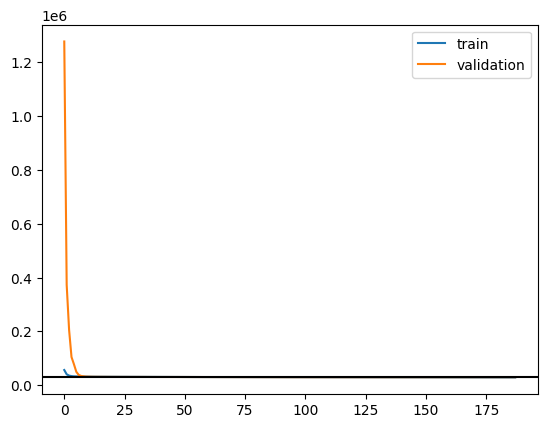

In [4]:
import matplotlib.pyplot as plt
%matplotlib inline

y = model.history['reconstruction_loss_validation']['reconstruction_loss_validation'].min()
plt.plot(model.history['reconstruction_loss_train']['reconstruction_loss_train'], label='train')
plt.plot(model.history['reconstruction_loss_validation']['reconstruction_loss_validation'], label='validation')

plt.axhline(y, c = 'k')

plt.legend()
plt.show()

In [2]:
import doubletdetection
from scipy.stats import median_abs_deviation as mad

In [6]:
def run_doubletdetection(adata):
    import doubletdetection

    clf = doubletdetection.BoostClassifier(
    n_iters=10,
    clustering_algorithm="louvain",
    standard_scaling=True,
    pseudocount=0.1,
    n_jobs=-1)
    doublets = clf.fit(adata.X).predict(p_thresh=1e-3, voter_thresh=0.5)
    doublet_score = clf.doublet_score()

    adata.obs["clf_doublet"] = doublets
    adata.obs["clf_score"] = doublet_score

    return adata

In [7]:
adata = run_doubletdetection(adata)
adata.obs

  0%|          | 0/10 [00:00<?, ?it/s]

,orig.ident,n_counts,n_genes,nReads,plate.barcode,mouse.id,tissue,subtissue,FACS.selection,mouse.sex,...,RNA_snn_res.0.5,seurat_clusters,doublet_score,doublet_class,leiden,louvain,MAGIC_leiden,MAGIC_louvain,clf_doublet,clf_score
A1.B000610.3_56_F.1.1,Bladder,119565.0,364,610727.0,B000610,3_56_F,Bladder,,Multiple,F,...,0,0,0.060606,Singlet,1,5,11,7,0.0,0.000242
A1.B002764.3_38_F.1.1,Bladder,3184.0,90,320035.0,B002764,3_38_F,Bladder,,Multiple,F,...,4,4,0.090909,Singlet,3,2,24,3,0.0,0.165940
A1.B002771.3_39_F.1.1,Bladder,197586.0,489,1044981.0,B002771,3_39_F,Bladder,,Multiple,F,...,0,0,0.066667,Singlet,1,5,14,4,0.0,0.000296
A1.D041914.3_8_M.1.1,Bladder,70714.0,405,447232.0,D041914,3_8_M,Bladder,,Multiple,M,...,0,0,0.030303,Singlet,0,5,1,5,0.0,0.020139
A1.D042253.3_9_M.1.1,Bladder,51411.0,528,330249.0,D042253,3_9_M,Bladder,,Multiple,M,...,0,0,0.115152,Singlet,1,0,6,6,0.0,0.111427
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
P8.MAA000487.3_10_M.1.1,Bladder,269238.0,637,1668602.0,MAA000487,3_10_M,Bladder,,Multiple,M,...,1,1,0.121212,Singlet,2,1,7,15,0.0,0.008221
P9.B000610.3_56_F.1.1,Bladder,121666.0,522,865291.0,B000610,3_56_F,Bladder,,Multiple,F,...,4,4,0.139394,Singlet,3,2,3,0,0.0,0.017267
P9.B002771.3_39_F.1.1,Bladder,187199.0,556,1056676.0,B002771,3_39_F,Bladder,,Multiple,F,...,1,1,0.151515,Singlet,2,3,21,1,0.0,0.043595
P9.D042253.3_9_M.1.1,Bladder,109706.0,612,493818.0,D042253,3_9_M,Bladder,,Multiple,M,...,3,3,0.072727,Singlet,0,4,1,5,0.0,0.233377


In [9]:
adata.obs.clf_doublet.unique()

array([0., 1.])

In [10]:
adata.obs.doublet_class.unique()

['Singlet', 'Doublet']
Categories (2, object): ['Doublet', 'Singlet']

In [11]:
adata.obs.clf_doublet = [ x for x in adata.obs.clf_doublet ]

A1.B000610.3_56_F.1.1      0.0
A1.B002764.3_38_F.1.1      0.0
A1.B002771.3_39_F.1.1      0.0
A1.D041914.3_8_M.1.1       0.0
A1.D042253.3_9_M.1.1       0.0
                          ... 
P8.MAA000487.3_10_M.1.1    0.0
P9.B000610.3_56_F.1.1      0.0
P9.B002771.3_39_F.1.1      0.0
P9.D042253.3_9_M.1.1       0.0
P9.MAA000487.3_10_M.1.1    0.0
Name: clf_doublet, Length: 1378, dtype: float64

In [12]:
for i in range(0, len(adata.obs.clf_doublet)):
    if adata.obs.clf_doublet[i] == 0:
        adata.obs.clf_doublet[i] = 'Singlet'
    else:
        adata.obs.clf_doublet[i] = 'Doublet'

/tmp/ipykernel_76/1715783652.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  adata.obs.clf_doublet[i] = 'Singlet'
